<h1 style="text-align:center; font-size: 36px;">Bayesian Statistics Project – 1</h1>
<h2 style="text-align:center; font-weight:normal; color:#555;">
Identifying optimal trading strategies for individual stocks
</h2>


### Introducing the project idea

Trading strategies generally propose a set of well defined rules that guide the market trader to perform profitable trades under appropriate assumptions. These rules include when to initiate and end the trading position, and in some cases, they may also include the quantity of stocks to be traded.

With a variety of trading strategies out there in the market, often some giving contradictory trading signals, it is important for the market trader to know which strategy works better for a particular stock. Most traders hone this knowledge via trial and error, and through experience they learn what is right and what is not. 

This project aims to enhance that learning process by applying the principles of Bayesian Statistics, thus providing a systematic framework to evaluate strategies. By doing so, it aims to offer concrete, data-driven insights that can help even novice traders make profitable trading decisions.

To better understand the project, we have divided it into three distinct sections, each describing a different Bayesian model to identify our ideal strategy. We begin by describing the dataset that shall be used throughout the analysis.

### Describing the dataset

The dataset consists of the daily closing prices of the BHARTIARTL stock over the last $2500$ trading days, contained between *1st September,2015* to *17th October,2025*. This data can be readily sourced from [Yahoo Finance](https://finance.yahoo.com/), which can be accessed in python via the **yfinance** library. 

We implement the data extraction process in [`fetch_data.py`](Stocks%20data/fetch_data.py) as given below. The dates and closing prices of the Airtel stock are saved in the csv file [`Airtel_stocks.csv`](Stocks%20data/Airtel_stocks.csv)

In [314]:
# Stocks data/fetch_data.py
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')

# Download Airtel stocks for the recent 1000 days
stocks = 'BHARTIARTL.NS'
data = yf.download(stocks, period='2500d', interval='1d')

# Extract the closing prices alone. 
data = data[['Close']].copy()
data.reset_index(inplace=True)

# save the data in a new csv file 
file = 'Stocks data/Airtel_stocks.csv'
data.to_csv(file, index=False)

# ----- Debugging ----- 

# # Plotting the graphs to check if the prices are loaded correctly once
# plt.figure(figsize=(10,5))
# plt.plot(data['Date'], data['Close'])
# plt.title('Bharti Airtel Closing Prices - Last 1000 Days')
# plt.xlabel('Date')
# plt.ylabel('Close Price')
# plt.grid(True)
# plt.show()

# print(data.tail())

[*********************100%***********************]  1 of 1 completed


### Choice of trading strategies

In the first two sections of this project, we choose to work with the following two trading strategies

1. **14-RSI + 5-RSI-EMA** strategy
2. **9-EMA + 21-EMA** crossover strategy

Detailed explanations of these strategies can be found [here](https://zerodha.com/varsity/chapter/indicators-part-1/) and [here](https://zerodha.com/varsity/chapter/indicators-part-2/). 

We compute the daily numerical values of both the indicators for our dataset in [`Compute_indicators.py`](Stocks%20data/Compute_indicators.py) as given below. The resulting values are stored in [`Airtel_indicator_values.csv`](Stocks%20data/Airtel_indicator_values.csv) for subsequent analysis.

In [315]:
import pandas as pd
import numpy as np

data = pd.read_csv('Stocks data/Airtel_stocks.csv', parse_dates=['Date'])
data['Close'] = pd.to_numeric(data['Close'], errors='coerce') # Convert to numeric data to avoid data type mismatch
# data = data.dropna(subset=['Close']) 
# Drops nan values (not needed)
data = data[['Date', 'Close']].copy()

# Computing the (9 + 21) EMA indicator values
data['EMA9'] = data['Close'].ewm(span=9, adjust=False).mean()
data['EMA21'] = data['Close'].ewm(span=21, adjust=False).mean()

# Computing the RSI values with 14 day lookback period 
delta = data['Close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(14, min_periods=14).mean()
avg_loss = pd.Series(loss).rolling(14, min_periods=14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# computing the RSI moving average with lookback period 5 
data['RSI_MA'] = data['RSI'].rolling(5, min_periods=5).mean()

# save the data
file = 'Stocks data/Airtel_indicator_values.csv'
data.to_csv(file, index=False)

# # ----- Debugging ----- 

# print(data.head())


## First Section - Simplified Bayesian Model

In this section, we implement a Bayesian model that allows us to find the probablity of success for both the above discussed strategies on the Airtel stock. The aim here is to maximize the number of profitable trades, and not necessarily the returns themselves.

Let $p_1$ and $p_2$ denote the probablity of success for the EMA and the RSI strategy respectively. Naturally, we consider the Beta-Binomial model, and define the priors $p_1 \sim \text{Beta}(1,1)$ and $p_2 \sim \text{Beta}(1,1)$.

This choice reflects our initial uncertainty about the strategies' efficiency, although the parameters can also be set based on historical performance.

Next, we identify **profitable days**, where the closing price exceeds the previous day's close. We then compare these with the daily signals generated by each strategy to determine how often the strategies align with the profitable movements.  

The implementation is available in [`simple_trading_model.py`](Simplified%20Model/simple_trading_model.py), with the snippet below showing the part relevant to our discussion.

In [316]:
# Simplified Model/simple_trading_model.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the indicator data
data = pd.read_csv('Stocks Data/Airtel_indicator_values.csv', index_col=0, parse_dates=True)

# Initially we let both priors be uniform(0, 1) or beta(1, 1)
prior = {
    'EMA_Crossover': {'alpha': 1, 'beta': 1},
    'RSI_Strategy': {'alpha': 1, 'beta': 1}
}

# Defining the rules for each trading strategy
data['EMA_signal'] = np.where(data['EMA9'] > data['EMA21'], 1, 0)
data['RSI_signal'] = np.where(data['RSI'] < data['RSI_MA'], 1, 0)

# Calculate next-day profit based on the trading signals
data['Close_next'] = data['Close'].shift(-1)
data['EMA_profit_actual'] = np.where((data['EMA_signal'] == 1) & (data['Close_next'] > data['Close']), 1, 0)
data['RSI_profit_actual'] = np.where((data['RSI_signal'] == 1) & (data['Close_next'] > data['Close']), 1, 0)
data = data[:-1]


### Bayesian updating of trading strategies

To update our understanding of the success probabilities $p_1$ (EMA crossover) and $p_2$ (RSI strategy), we simulate a sequence of $n$ trades for each strategy independently. We track the fraction of profitable trades, denoted by $y_1$ and $y_2$, to sequentially update the respective priors.  

**Note:** A "trade" does not necessarily mean buying or selling a stock, it may also indicate maintaining the current position. By $n$ trades, we refer to $n$ decision points where a trading action is considered.

We use closing prices from day 100 to day 1999 to perform sequential updates of the priors. For flexibility, this 1900-day period is divided into equal-sized batches, with equally spaced trades in each batch. In this analysis:  

- **Batch size:** 50 days  
- **Trades per batch:** 20 approx (roughly one trade every 2–3 days)  

For each batch, we compute:

- The fraction of profitable trades $y_1$ and $y_2$  
- The posterior means for each strategy  

All these results are stored in the CSV file [`results.csv`](Simplified%20Model/results.csv) for further analysis.


In [317]:
# Simplified Model/simple_training_model.py
train_data = data.iloc[100:2000].copy()

# Hyperparameters
interval_size = 50
trades = 20
results = []
rsi_win = 0
ema_win = 0
tie = 0

num_intervals = len(train_data) // interval_size

for idx in range(num_intervals):
    start = idx * interval_size
    end = start + interval_size
    interval_data = train_data.iloc[start:end]

    # Equally spaced trade indices in this interval
    step = len(interval_data) // trades
    trade_indices = np.arange(0, len(interval_data), step)[:trades]

    # Subset of trades that are profitable
    ema_signal_data = interval_data.iloc[trade_indices][interval_data.iloc[trade_indices]['EMA_signal'] == 1]
    rsi_signal_data = interval_data.iloc[trade_indices][interval_data.iloc[trade_indices]['RSI_signal'] == 1]

    # Count successes and total signals
    ema_success = ema_signal_data['EMA_profit_actual'].sum()
    rsi_success = rsi_signal_data['RSI_profit_actual'].sum()
    ema_total = len(ema_signal_data)
    rsi_total = len(rsi_signal_data)

    # Compute success rates (avoid division by zero)
    ema_rate = ema_success / ema_total if ema_total > 0 else 0
    rsi_rate = rsi_success / rsi_total if rsi_total > 0 else 0

    # Update priors
    ema_fail = ema_total - ema_success
    rsi_fail = rsi_total - rsi_success
    prior['EMA_Crossover']['alpha'] += ema_success
    prior['EMA_Crossover']['beta'] += ema_fail
    prior['RSI_Strategy']['alpha'] += rsi_success
    prior['RSI_Strategy']['beta'] += rsi_fail

    # Posterior means after this interval
    posterior_means = {
        'EMA_Crossover': prior['EMA_Crossover']['alpha'] / (prior['EMA_Crossover']['alpha'] + prior['EMA_Crossover']['beta']),
        'RSI_Strategy': prior['RSI_Strategy']['alpha'] / (prior['RSI_Strategy']['alpha'] + prior['RSI_Strategy']['beta'])
    }

    if rsi_rate > ema_rate:
        rsi_win += 1
    elif ema_rate > rsi_rate:
        ema_win += 1
    else:
        tie += 1

    results.append({
        'Interval': idx,
        'EMA_success_rate': ema_rate,
        'RSI_success_rate': rsi_rate,
        'EMA_alpha': prior['EMA_Crossover']['alpha'],
        'EMA_beta': prior['EMA_Crossover']['beta'],
        'RSI_alpha': prior['RSI_Strategy']['alpha'],
        'RSI_beta': prior['RSI_Strategy']['beta'],
        'EMA_posterior': posterior_means['EMA_Crossover'],
        'RSI_posterior': posterior_means['RSI_Strategy'],
    })

# Save results to csv file 
results_df = pd.DataFrame(results)
results_df.to_csv('Simplified Model/results.csv', index=False)


### Summary

We summarize the results of the sequential Bayesian updating over batches of trades. For each batch, we identify which strategy performed better by comparing the number of profitable trades.

From the analysis, we can conclude the following:

- The RSI strategy generally outperforms EMA, as seen in its higher mean success rate and lower variance.
- RSI also wins in a larger number of intervals compared to EMA.
- The posterior mean plots further support this conclusion, showing consistently higher posterior success probability for RSI across intervals.

These observations highlight that RSI may be a more reliable strategy for this stock, based on both historical profits and updated posterior estimations.


--- performance summary ---
RSI better in 23 out of 38 intervals
EMA better in 15 out of 38 intervals
Equal performance in 0 intervals

--- statistical summary ---
EMA success rate -> mean: 0.461
                    variance: 0.051
RSI success rate -> mean: 0.503
                    variance: 0.025


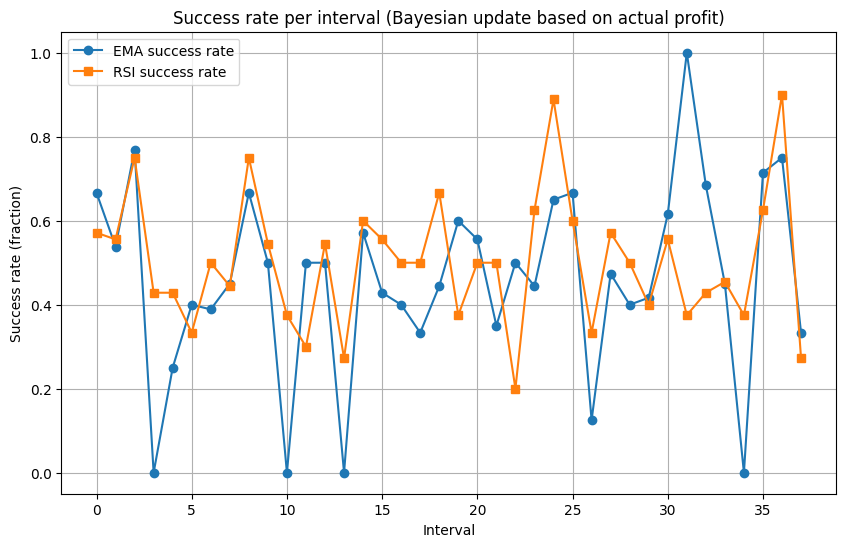

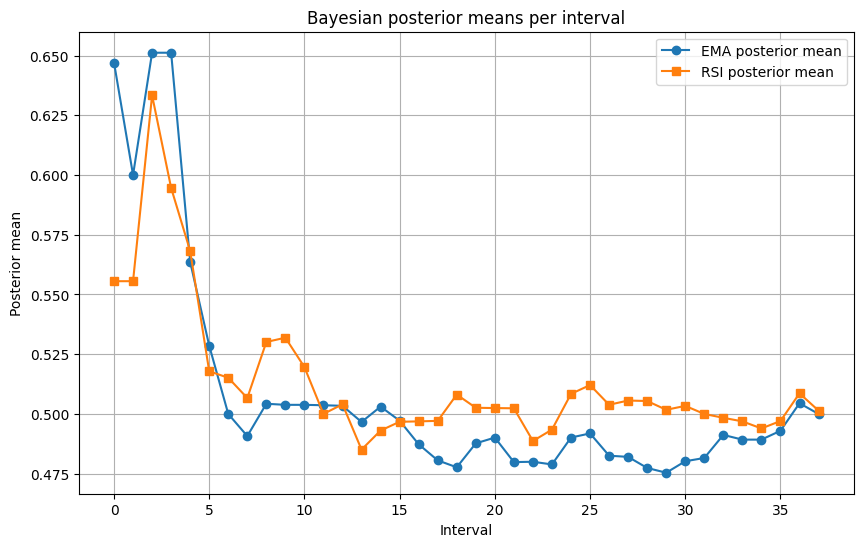

In [318]:
# Simplified Model/simple_trading_model.py
# Performance summary
print("\n--- performance summary ---")
print(f"RSI better in {rsi_win} out of {num_intervals} intervals")
print(f"EMA better in {ema_win} out of {num_intervals} intervals")
print(f"Equal performance in {tie} intervals")

# Statistical summary
ema_mean = results_df['EMA_success_rate'].mean()
ema_var = results_df['EMA_success_rate'].var(ddof=1)
rsi_mean = results_df['RSI_success_rate'].mean()
rsi_var = results_df['RSI_success_rate'].var(ddof=1)

print("\n--- statistical summary ---")
print(f"EMA success rate -> mean: {ema_mean:.3f}")
print(f"                    variance: {ema_var:.3f}")
print(f"RSI success rate -> mean: {rsi_mean:.3f}")
print(f"                    variance: {rsi_var:.3f}")

# Plot success rate per interval
plt.figure(figsize=(10,6))
plt.plot(results_df['Interval'], results_df['EMA_success_rate'], marker='o', label='EMA success rate')
plt.plot(results_df['Interval'], results_df['RSI_success_rate'], marker='s', label='RSI success rate')
plt.xlabel('Interval')
plt.ylabel('Success rate (fraction)')
plt.title('Success rate per interval (Bayesian update based on actual profit)')
plt.grid(True)
plt.legend()
plt.savefig("Simplified Model/success_rate_per_interval.png")
plt.show()

# Plot posterior means per interval
plt.figure(figsize=(10,6))
plt.plot(results_df['Interval'], results_df['EMA_posterior'], marker='o', label='EMA posterior mean')
plt.plot(results_df['Interval'], results_df['RSI_posterior'], marker='s', label='RSI posterior mean')
plt.xlabel('Interval')
plt.ylabel('Posterior mean')
plt.title('Bayesian posterior means per interval')
plt.grid(True)
plt.legend()
plt.savefig("Simplified Model/posterior_means_per_interval.png")
plt.show()


### Simple testing

From our previous analysis, we found that the RSI strategy generally outperforms the EMA strategy. To validate this observation, we test this theory on the last 500 days of stock prices. The testing code for this procedure is implemented in [`simple_testing.py`](Simplified%20Model/simple_testing.py), where trades are executed every 10 days.

The results from this testing show that the RSI strategy has a higher probability of success compared to the EMA strategy. The computed success rates for both strategies are summarized in [`summary.csv`](Simplified%20Model/summary.csv).

This approach allows us to verify that the trend observed in our earlier training (from 100th to 1999th day) also holds in a recent, unseen period, reinforcing the reliability of the RSI strategy for this dataset.


In [319]:
# Simplified Model/simple_testing.py
import pandas as pd
import numpy as np
import yfinance as yf

# Load the recent 500 days price data
stock = "BHARTIARTL.NS"
data = yf.download(stock, period='500d', interval='1d')

# Flatten multi-index if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Data cleaning
data = data.reset_index()[['Date', 'Close']].copy()
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
data.dropna(subset=['Close'], inplace=True)

# Compute EMA(9) and EMA(21)
data['EMA9'] = data['Close'].ewm(span=9, adjust=False).mean()
data['EMA21'] = data['Close'].ewm(span=21, adjust=False).mean()

# Compute RSI(14)
delta = data['Close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(14, min_periods=14).mean()
avg_loss = pd.Series(loss).rolling(14, min_periods=14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# RSI moving average (5-day)
data['RSI_MA'] = data['RSI'].rolling(5, min_periods=5).mean()

# Trading signals
data['EMA_signal'] = (data['EMA9'] > data['EMA21']).astype(int)
data['RSI_signal'] = (data['RSI'] < data['RSI_MA']).astype(int)

# Profit computation
data['Close_next'] = data['Close'].shift(-1)
data['Profit'] = (data['Close_next'] > data['Close']).astype(int)
data.dropna(inplace=True)

# Forward testing every 10 days
test_data = data.tail(500).copy()
trades = 10
indices = np.arange(0, len(test_data), trades)

ema_trades = test_data.iloc[indices][test_data.iloc[indices]['EMA_signal'] == 1]
rsi_trades = test_data.iloc[indices][test_data.iloc[indices]['RSI_signal'] == 1]
ema_win = ema_trades['Profit'].sum()
rsi_win = rsi_trades['Profit'].sum()

# Relative success rates
ema_success_rate = (ema_win / len(ema_trades)) if len(ema_trades) > 0 else 0
rsi_success_rate = (rsi_win / len(rsi_trades)) if len(rsi_trades) > 0 else 0

print("\nTesting every 10 days (success probabilities):")
print(f"EMA strategy: {ema_success_rate:.3f}")
print(f"RSI strategy: {rsi_success_rate:.3f}")

# Save summary with relative success rates
results = pd.DataFrame({
    'Strategy': ['EMA_Crossover', 'RSI_Strategy'],
    'Success_Probability': [ema_success_rate, rsi_success_rate]
})
results.to_csv('Simplified Model/summary.csv', index=False)


[*********************100%***********************]  1 of 1 completed


Testing every 10 days (success probabilities):
EMA strategy: 0.514
RSI strategy: 0.542


### Bayesian testing

In this other form of testing, we start with the prior as the posterior beta distribution from the training phase instead of taking $Beta(1, 1)$ for both strategies. Naturally, since we start from a knowledgeable prior, our success rates should be higher compared to the training phase.

We implement this in [`Bayesian_testing.py`](Simplified%20Model/Bayesian_testing.py). Clearly, the mean success rates for both the strategies have increased with a higher observed increase in the RSI strategy.


--- Training vs Testing Success Rate Summary ---
Strategy  Training_Mean  Training_Var  Testing_Mean  Testing_Var
     EMA       0.508912      0.002295      0.514882     0.042382
     RSI       0.514103      0.000916      0.579333     0.020971


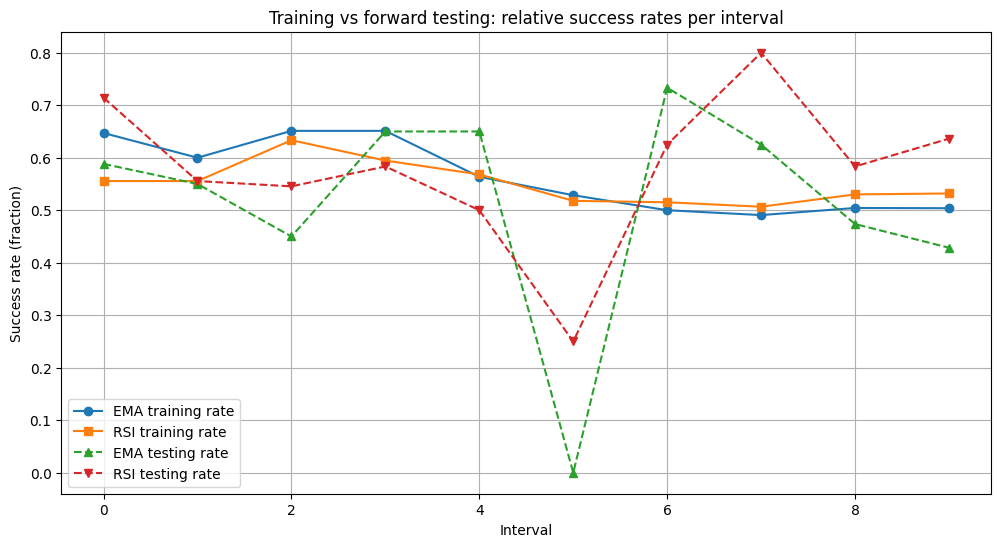

In [1]:
# Simplified Model/Bayesian_testing.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load indicator data
data = pd.read_csv('Stocks Data/Airtel_indicator_values.csv', index_col=0, parse_dates=True)

# Load training results to get final posterior alpha and beta and success rates
train_results = pd.read_csv('Simplified Model/results.csv')

# Initialize priors from training
prior = {
    'EMA_Crossover': {'alpha': train_results['EMA_alpha'].iloc[-1],
                      'beta': train_results['EMA_beta'].iloc[-1]},
    'RSI_Strategy': {'alpha': train_results['RSI_alpha'].iloc[-1],
                     'beta': train_results['RSI_beta'].iloc[-1]}
}

# Trading signals
data['EMA_signal'] = np.where(data['EMA9'] > data['EMA21'], 1, 0)
data['RSI_signal'] = np.where(data['RSI'] < data['RSI_MA'], 1, 0)
data['Close_next'] = data['Close'].shift(-1)
data['EMA_profit_actual'] = np.where((data['EMA_signal'] == 1) & (data['Close_next'] > data['Close']), 1, 0)
data['RSI_profit_actual'] = np.where((data['RSI_signal'] == 1) & (data['Close_next'] > data['Close']), 1, 0)
data = data[:-1]

test_data = data.iloc[2000:].copy()

# Hyperparameters
interval_size = 50
trades = 20
results = []
rsi_win = 0
ema_win = 0
tie = 0

num_intervals = len(test_data) // interval_size

for idx in range(num_intervals):
    start = idx * interval_size
    end = start + interval_size
    interval_data = test_data.iloc[start:end]

    step = len(interval_data) // trades
    trade_indices = np.arange(0, len(interval_data), step)[:trades]

    ema_signal_data = interval_data.iloc[trade_indices][interval_data.iloc[trade_indices]['EMA_signal'] == 1]
    rsi_signal_data = interval_data.iloc[trade_indices][interval_data.iloc[trade_indices]['RSI_signal'] == 1]

    ema_success = ema_signal_data['EMA_profit_actual'].sum()
    ema_total = len(ema_signal_data)
    rsi_success = rsi_signal_data['RSI_profit_actual'].sum()
    rsi_total = len(rsi_signal_data)

    if ema_total > 0:
        ema_rate = ema_success / ema_total
    else:
        ema_rate = np.mean([r['EMA_success_rate'] for r in results[-5:]]) if len(results) >= 5 else 0

    if rsi_total > 0:
        rsi_rate = rsi_success / rsi_total
    else:
        rsi_rate = np.mean([r['RSI_success_rate'] for r in results[-5:]]) if len(results) >= 5 else 0

    # Update priors
    prior['EMA_Crossover']['alpha'] += ema_success
    prior['EMA_Crossover']['beta'] += ema_total - ema_success
    prior['RSI_Strategy']['alpha'] += rsi_success
    prior['RSI_Strategy']['beta'] += rsi_total - rsi_success

    posterior_means = {
        'EMA_Crossover': prior['EMA_Crossover']['alpha'] / (prior['EMA_Crossover']['alpha'] + prior['EMA_Crossover']['beta']),
        'RSI_Strategy': prior['RSI_Strategy']['alpha'] / (prior['RSI_Strategy']['alpha'] + prior['RSI_Strategy']['beta'])
    }

    if rsi_rate > ema_rate:
        rsi_win += 1
    elif ema_rate > rsi_rate:
        ema_win += 1
    else:
        tie += 1

    results.append({
        'Interval': idx,
        'EMA_success_rate': ema_rate,
        'RSI_success_rate': rsi_rate,
        'EMA_posterior': posterior_means['EMA_Crossover'],
        'RSI_posterior': posterior_means['RSI_Strategy']
    })

# Save forward testing results
results_df = pd.DataFrame(results)
results_df.to_csv('Simplified Model/bayesian_testing_results.csv', index=False)

# Compute mean and variance for both training and testing
summary_stats = pd.DataFrame({
    'Strategy': ['EMA', 'RSI'],
    'Training_Mean': [train_results['EMA_posterior'].mean(), train_results['RSI_posterior'].mean()],
    'Training_Var': [train_results['EMA_posterior'].var(ddof=1), train_results['RSI_posterior'].var(ddof=1)],
    'Testing_Mean': [results_df['EMA_success_rate'].mean(), results_df['RSI_success_rate'].mean()],
    'Testing_Var': [results_df['EMA_success_rate'].var(ddof=1), results_df['RSI_success_rate'].var(ddof=1)]
})

print("\n--- Training vs Testing Success Rate Summary ---")
print(summary_stats.to_string(index=False))

# Plot relative success rates
train_plot_df = train_results.head(10)
test_plot_df = results_df.head(10)

plt.figure(figsize=(12,6))
plt.plot(train_plot_df['Interval'], train_plot_df['EMA_posterior'], marker='o', label='EMA training rate')
plt.plot(train_plot_df['Interval'], train_plot_df['RSI_posterior'], marker='s', label='RSI training rate')
plt.plot(test_plot_df['Interval'], test_plot_df['EMA_success_rate'], marker='^', linestyle='--', label='EMA testing rate')
plt.plot(test_plot_df['Interval'], test_plot_df['RSI_success_rate'], marker='v', linestyle='--', label='RSI testing rate')
plt.xlabel('Interval')
plt.ylabel('Success rate (fraction)')
plt.title('Training vs forward testing: relative success rates per interval')
plt.grid(True)
plt.legend()
plt.savefig("Simplified Model/Training_vs_testing_success_rates.png")
plt.show()


### Limitations of the simplified Bayesian model

The simplified Bayesian model has a few clear limitations:  

- We only consider whether a trade is profitable or not, ignoring the actual profit or loss for each trade. A single large loss could outweigh multiple profitable trades.  
- Some intervals may have no trading actions, which can act as outliers and distort success rate calculations and plots.  

To address these issues, we introduce an improvised version of the model that tracks not only the probability of success for each strategy but also the actual profits made, therefore yielding better results.


## Second section : Complex Bayesian Model

In this improvised version, along with using a Beta-Binomial model to estimate the probablity of success for each strategy, we also consider the Normal-Normal conjugate model with known variance to compute the returns from each strategy. Mathemetically, if $p_1$ and $p_2$ denote the probability of success for the EMA and RSI strategy, and $r_1$ and $r_2$ denote their corresponding returns, we have the following priors

- $p_1 \sim Beta(1, 1)$
- $p_2 \sim Beta(1, 1)$
- $r_1 \sim \mathcal{N}(\mu_1, \sigma_0^2)$
- $\mu_1 \sim \mathcal{N}(0, \tau_0^2)$
- $r_2 \sim \mathcal{N}(\mu_2, \sigma_0^2)$,
- $\mu_2 \sim \mathcal{N}(0, \tau_0^2)$

where $\tau_0^2 = 0.0004$ is the empirical prior variance, and $\sigma_0^2 = 0.0004$ is the chosen noise variance for returns. Additionally, we let the mean return to be zero for both the priors, which otherwise can be replaced by values obtained from historical data as well.

We implement this in the following code snippet from [`complex_traing_model.py`](Complex%20Model/complex_trading_model.py). The training dataset, number of batches, and the number of trades in each batch is exactly the same as in the first section.

In [321]:
# Complex Model/complex_trading_model.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load indicator data
data = pd.read_csv('Stocks Data/Airtel_indicator_values.csv', index_col=0, parse_dates=True)

# initialize priors for each strategy
prior = {
    'EMA_crossover': {'alpha': 1.0, 'beta': 1.0, 'mu': 0.0, 'tau2': 0.0004},
    'RSI_strategy': {'alpha': 1.0, 'beta': 1.0, 'mu': 0.0, 'tau2': 0.0004}
}
sigma2 = 0.0004   # empirical noise variance
s = 100.0         # scaling factor for profit
M = 5.0           # clipping threshold

# trading rules
data['EMA_signal'] = (data['EMA9'] > data['EMA21']).astype(int)
data['RSI_signal'] = (data['RSI'] < data['RSI_MA']).astype(int)

# compute next-day return
data['close_next'] = data['Close'].shift(-1)
data['return'] = (data['close_next'] - data['Close']) / data['Close']
data = data.dropna().reset_index(drop=True)

# training data
train_data = data.iloc[100:2000].copy()

# hyperparameters
interval_size = 50
trades = 20
results = []
num_intervals = len(train_data) // interval_size

### Updating the Bayesian Parameters

We describe how this model updates the Bayesian parameters for both components as follows.

#### Updating the Beta-Binomial Model

Let $p_1 \sim \text{Beta}(\alpha_1, \beta_1)$ and $p_2 \sim \text{Beta}(\alpha_2, \beta_2)$ and let $r$ denote the return for the day. Let $s$ be a scaling factor to ensure the updates affect the priors significantly enough, and let $M$ be a bound to avoid outliers from huge returns in terms of magnitude.

Then, we define a new parameter $\delta = min(max(-M, s * r), M)$ which ensures that the scaled return $s * r$ stays between $-M$ and $M$.Subsequently, the Beta priors are updated as follows:

- If $r > 0$, i.e. the day yielded a profit,  we have $\alpha_1^{\prime} = \alpha_1 + 1 + \max(0, \delta)$ and $\beta_1^{\prime} = \beta_1$

- Otherwise if $r \le 0$, the day experiences a loss, we have $\alpha_1^{\prime} = \alpha_1$ and $\beta_1^{\prime} = \beta_1 + 1 + \max(0, -\delta)$.

Note that these updates are analogous to those in the first section, with the difference being the inclusion of the profit-adjusted term $\max(0, |\delta|)$

#### Updating the Normal-Normal Model

The Normal-Normal model update with known variance is the standard one, with sample size $n=1$ and return $r$, as implemented in [`complex_training_model.py`](Complex%20Model/complex_trading_model.py). Here, the posterior mean and variance are updated per trade based on the observed return.


The code also summarizes the results in a tablular format and saves them in [`results_with_weighted_beta.csv`](Complex%20Model/results_with_weighted_beta.csv), which includes interval-level and cumulative profits, as well as posterior parameters for both strategies.


In [322]:

# Complex Model/complex_trading_model.py
# for plotting
profit_history = {s: [] for s in prior}
posterior_return_history = {s: [] for s in prior}
posterior_prob_history = {s: [] for s in prior}

# track running cumulative profit across intervals
cum_profits = {s: 0.0 for s in prior}

# store PPD variance
ppd_variance_history = {s: [] for s in prior}

# Updating the bayesian paramaters
for idx in range(num_intervals):
    start = idx * interval_size
    end = start + interval_size
    interval_data = train_data.iloc[start:end]

    # equally spaced trades
    step = len(interval_data) // trades
    trade_indices = np.arange(0, len(interval_data), step)[:trades]

    total_profits = {s: 0.0 for s in prior}

    for t_idx in trade_indices:
        row = interval_data.iloc[t_idx]

        for strat in prior:
            signal_col = 'EMA_signal' if strat == 'EMA_crossover' else 'RSI_signal'
            r_t = row['return']

            if row[signal_col] == 1:
                # weighted beta update based on profit
                c = np.clip(s * r_t, -M, M)
                prior[strat]['alpha'] += 1.0 + max(0.0, c)
                prior[strat]['beta']  += 1.0 + max(0.0, -c)

                # normal-normal update for return magnitude
                mu, tau2 = prior[strat]['mu'], prior[strat]['tau2']
                q_old = 1.0 / tau2
                q_new = q_old + 1.0 / sigma2
                mu_new = (q_old * mu + r_t / sigma2) / q_new
                tau2_new = 1.0 / q_new
                prior[strat]['mu'], prior[strat]['tau2'] = mu_new, tau2_new

                total_profits[strat] += r_t

    # update running cumulative profits
    for strat in cum_profits:
        cum_profits[strat] += total_profits[strat]

    # posterior mean (probability)
    posterior_means = {s: prior[s]['alpha'] / (prior[s]['alpha'] + prior[s]['beta']) for s in prior}

    # compute PPD variance
    for strat in prior:
        ppd_var = sigma2 + prior[strat]['tau2']
        ppd_variance_history[strat].append(ppd_var)

    results.append({
        'Interval': idx,
        'EMA_alpha': prior['EMA_crossover']['alpha'],
        'EMA_beta': prior['EMA_crossover']['beta'],
        'RSI_alpha': prior['RSI_strategy']['alpha'],
        'RSI_beta': prior['RSI_strategy']['beta'],
        'EMA_posterior': posterior_means['EMA_crossover'],
        'RSI_posterior': posterior_means['RSI_strategy'],
        'EMA_interval_profit': total_profits['EMA_crossover'],
        'RSI_interval_profit': total_profits['RSI_strategy'],
        'EMA_cum_profit': cum_profits['EMA_crossover'],
        'RSI_cum_profit': cum_profits['RSI_strategy'],
        'EMA_posterior_return': prior['EMA_crossover']['mu'],
        'RSI_posterior_return': prior['RSI_strategy']['mu'],
        'EMA_ppd_var': ppd_variance_history['EMA_crossover'][-1],
        'RSI_ppd_var': ppd_variance_history['RSI_strategy'][-1]
    })

    for strat in prior:
        profit_history[strat].append(total_profits[strat])
        posterior_return_history[strat].append(prior[strat]['mu'])
        posterior_prob_history[strat].append(posterior_means[strat])

# save results 
results_df = pd.DataFrame(results)
results_df.to_csv('Complex Model/results_with_weighted_beta.csv', index=False)

### Summary

Similar to the first section, the results show consistent numerical trends favoring the RSI strategy over the EMA strategy. Specifically:

- The RSI strategy exhibits higher posterior means for both returns and the fraction of successful trades, accompanied by lower variance compared to the EMA strategy.
- The mean profit achieved from the RSI strategy is higher than that of the EMA strategy.

These trends are also reflected in the plots:

- The first plot shows the profit per interval for both strategies. While the values fluctuate across intervals, the RSI strategy appears to have marginally better profits in a few intervals.
- The second plot shows cumulative profits across the intervals. Here, the RSI strategy clearly outperforms EMA, with a final cumulative return of approximately 0.78 for RSI versus 0.24 for EMA.
- The final two plots depict the posterior mean returns and the posterior success probabilities for each strategy. The plots appear similar, suggesting a direct relationship between mean success probability and mean return for this dataset. However, this relationship may not always hold for other datasets.



Complex model summary statistics
     strategy  profit_mean  profit_var  posterior_return_mean  posterior_return_var  posterior_prob_mean  posterior_prob_var
EMA_crossover     0.006528    0.004474              -0.000955              0.000002             0.480280            0.000478
 RSI_strategy     0.020652    0.005474               0.000914              0.000002             0.511645            0.000402


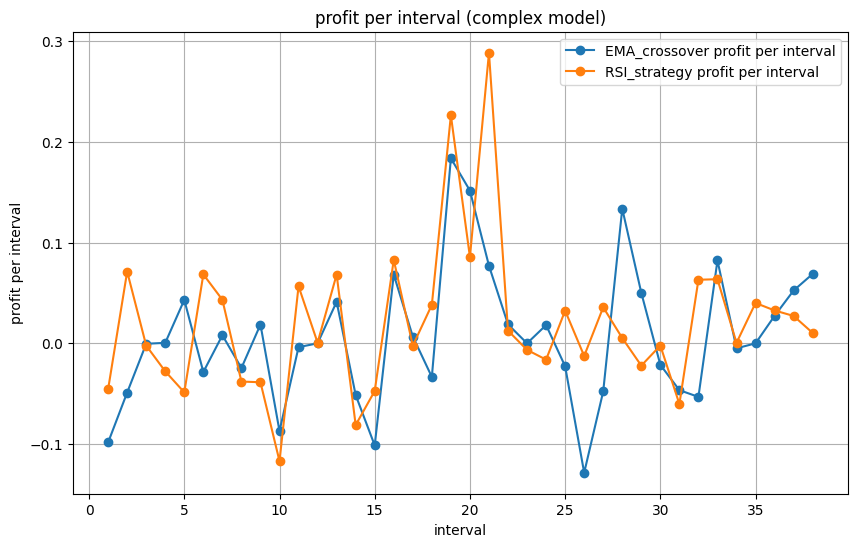

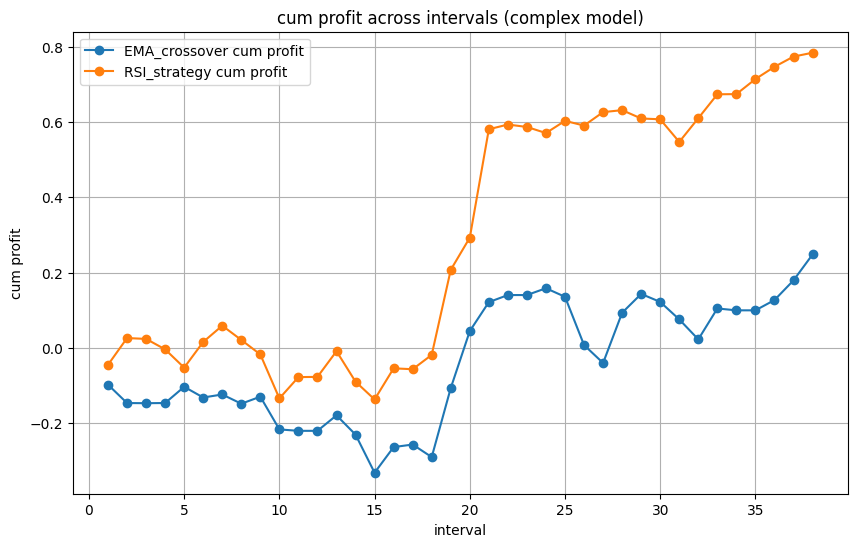

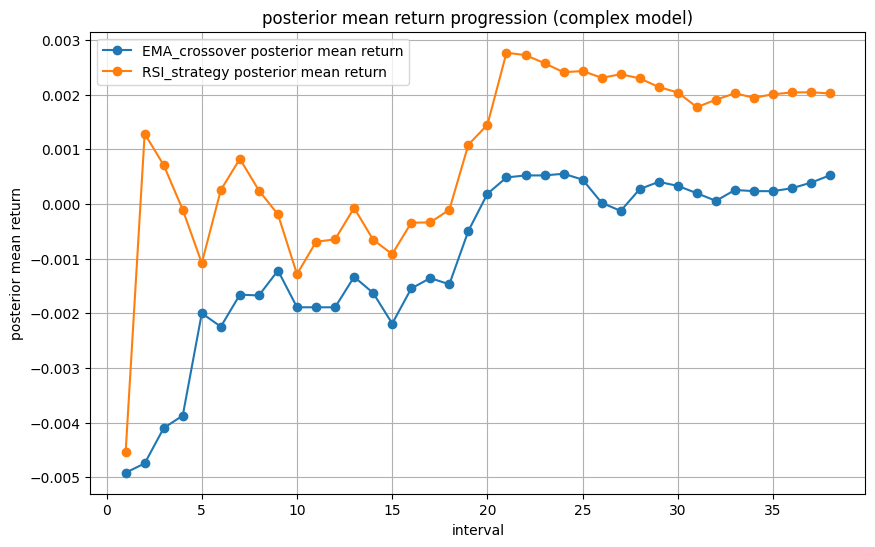

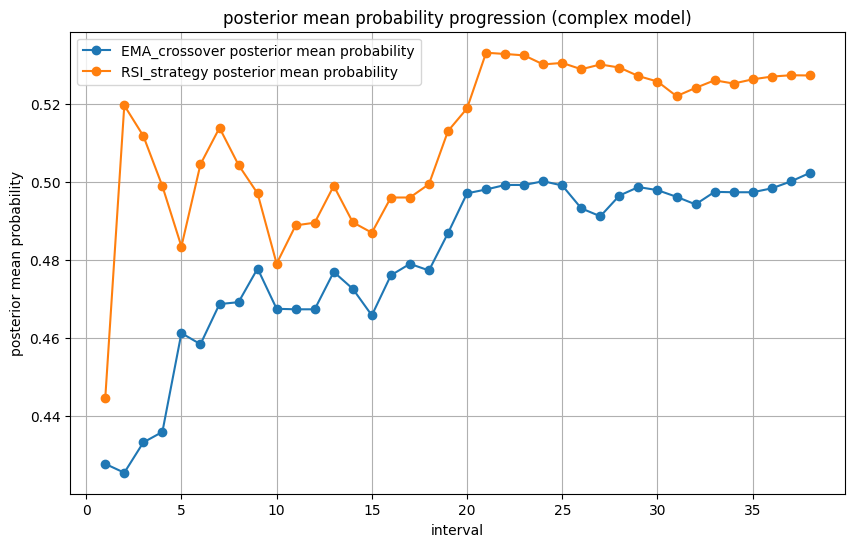

In [323]:

# Complex Model/complex_trading_model.py
# create dataframes for plotting
profits_df = pd.DataFrame(profit_history)
posterior_return_df = pd.DataFrame(posterior_return_history)
posterior_prob_df = pd.DataFrame(posterior_prob_history)

# Summary statistics
summary_stats = pd.DataFrame({
    'strategy': [s for s in prior],
    'profit_mean': [profits_df[s].mean() for s in prior],
    'profit_var': [profits_df[s].var(ddof=1) for s in prior],
    'posterior_return_mean': [posterior_return_df[s].mean() for s in prior],
    'posterior_return_var': [posterior_return_df[s].var(ddof=1) for s in prior],
    'posterior_prob_mean': [posterior_prob_df[s].mean() for s in prior],
    'posterior_prob_var': [posterior_prob_df[s].var(ddof=1) for s in prior],
})
print("\nComplex model summary statistics")
print(summary_stats.to_string(index=False))

# Profit per interval plot
plt.figure(figsize=(10,6))
for strat in prior:
    plt.plot(profits_df.index+1, profits_df[strat], marker='o', label=f'{strat} profit per interval')
plt.xlabel('interval')
plt.ylabel('profit per interval')
plt.title('profit per interval (complex model)')
plt.grid(True)
plt.legend()
plt.savefig('Complex Model/profit_per_interval.png')
plt.show()

# Cumulative profit plot 
plt.figure(figsize=(10,6))
for strat in prior:
    plt.plot(profits_df.index+1, profits_df[strat].cumsum(), marker='o', label=f'{strat} cum profit')
plt.xlabel('interval')
plt.ylabel('cum profit')
plt.title('cum profit across intervals (complex model)')
plt.grid(True)
plt.legend()
plt.savefig('Complex Model/cum_profit.png')
plt.show()

# Posterior mean return plot
plt.figure(figsize=(10,6))
for strat in prior:
    plt.plot(posterior_return_df.index+1, posterior_return_df[strat], marker='o', label=f'{strat} posterior mean return')
plt.xlabel('interval')
plt.ylabel('posterior mean return')
plt.title('posterior mean return progression (complex model)')
plt.grid(True)
plt.legend()
plt.savefig('Complex Model/posterior_mean_return_progression.png')
plt.show()

# Posterior mean probability plot
plt.figure(figsize=(10,6))
for strat in prior:
    plt.plot(posterior_prob_df.index+1, posterior_prob_df[strat], marker='o', label=f'{strat} posterior mean probability')
plt.xlabel('interval')
plt.ylabel('posterior mean probability')
plt.title('posterior mean probability progression (complex model)')
plt.grid(True)
plt.legend()
plt.savefig('Complex Model/posterior_mean_probability_progression.png')
plt.show()




### Posterior Predictive Distribution Analysis

The Posterior Predictive Distribution $P(r_{\text{new}} \mid r)$ for the Normal–Normal model with known variance is computed in the following fashion. If the posterior for the mean return is $\mathcal{N}(\mu_{\text{post}}, \tau^2)$ and the data variance is $\sigma^2$, then $P(r_{\text{new}} \mid r) \sim \mathcal{N}(\mu_{\text{post}}, \tau^2 + \sigma^2)$.  

#### 1. Posterior Predictive Probability
For each interval, we compute the probability that the next trade’s return exceeds a target value $r^*$, i.e. $P(r > r^*)$. Two targets are considered: $r^* = 0$ (non-negative return) and $r^* = 0.001$ (0.1% positive return).  

The **RSI strategy** consistently shows higher predictive probabilities in both targets, which can be seen from the first two plots and the higher mean returns in the summary table.

#### 2. Posterior Predictive Intervals
The $95$% predictive intervals for each strategy are computed as $\mu_{\text{post}} \pm 1.96 \sqrt{\tau^2 + \sigma^2}$ for each interval.
These intervals represent the range in which we expect the next-trade return to lie with a certain probability. 

Both the mean upper and lower limits of these intervals are higher for the RSI strategy, further supporting its stronger posterior performance relative to EMA. This is also reflected in the third plot.

#### 3. Comparison Between Strategies
The probability that the EMA strategy outperforms the RSI strategy is given by $P(\text{EMA} > \text{RSI}) = 1 - \Phi\Big((\mu_{\text{RSI}} - \mu_{\text{EMA}}) / \sqrt{\tau_{\text{EMA}}^2 + \tau_{\text{RSI}}^2 + 2\sigma^2}\Big)$, where $\Phi$ denotes the CDF of the standard normal distribution.  

The resulting probability remains around **0.47** with very low variance, suggesting that RSI outperforms EMA by roughly **3%** on average. The final plot further bolsters these numbers.

The full implementation can be found in [`PPD.py`](Complex%20Model/PPD.py).



Posterior Predictive Summary Statistics
     strategy  ppd_prob_mean_r0  ppd_prob_var_r0  ppd_prob_mean_r001  ppd_prob_var_r001  ppd_ci_lower_mean  ppd_ci_upper_mean
EMA_crossover          0.481254         0.000919            0.461500           0.000904          -0.040324           0.038414
 RSI_strategy          0.518260         0.000934            0.498482           0.000926          -0.038500           0.040327

Comparison Summary (Probability that EMA beats RSI)
comparison  mean_prob  var_prob
 EMA > RSI   0.473836  0.000212


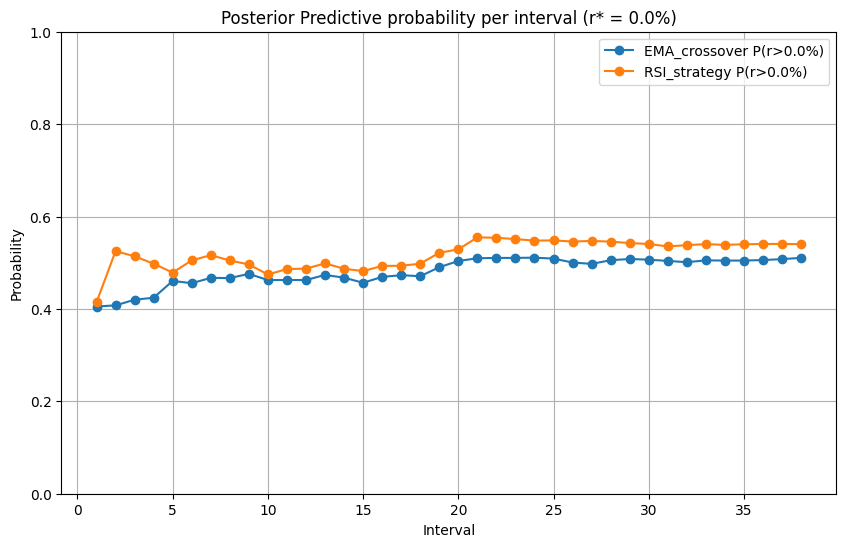

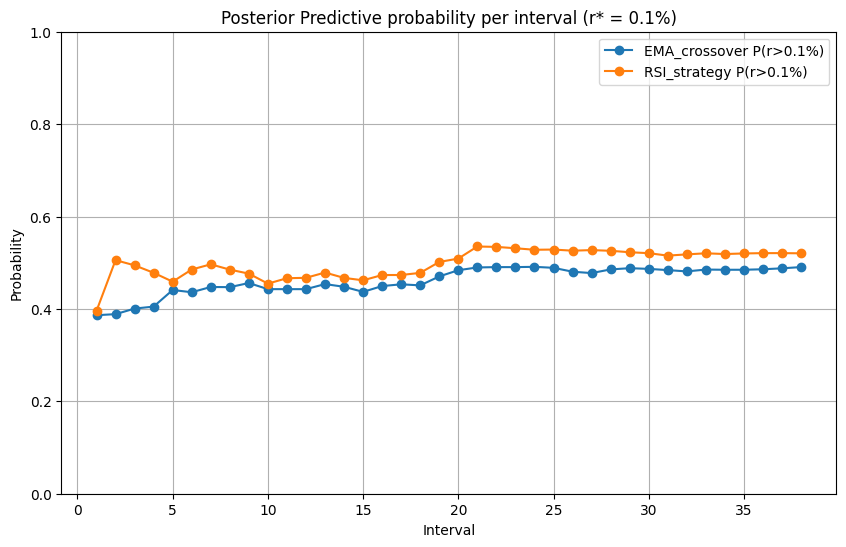

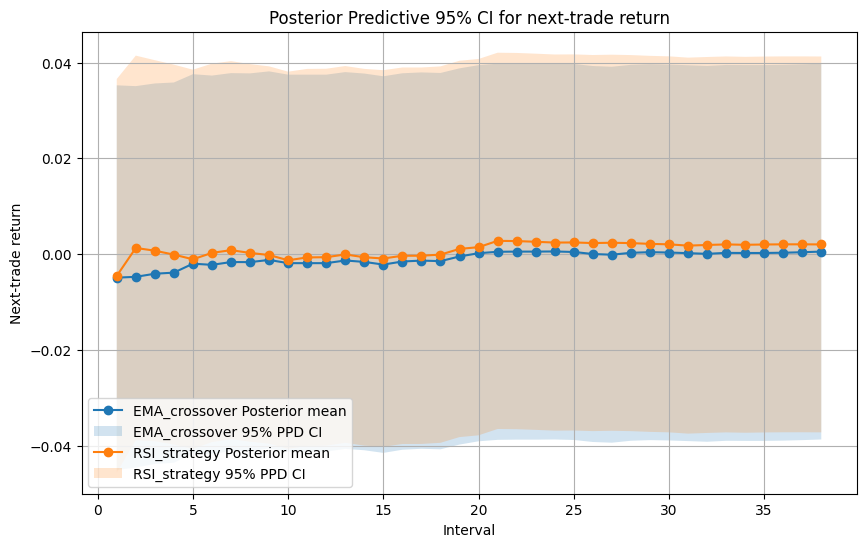

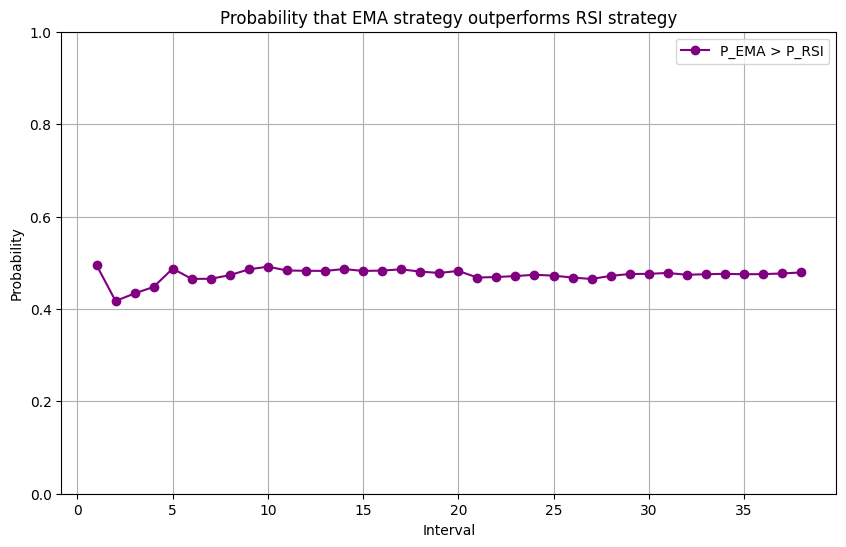

In [324]:
# Complex Model/PPD.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load results from training
results_df = pd.read_csv('Complex Model/results_with_weighted_beta.csv')

strategies = ['EMA_crossover', 'RSI_strategy']
r_targets = [0.0, 0.001]  # 0% and 0.1%

ppd_prob_dfs = {}
ppd_lower_ci = {}
ppd_upper_ci = {}

# Compute posterior predictive probabilities and CI
for strat in strategies:
    mu = results_df[f'{strat[:3]}_posterior_return'].values
    var = results_df[f'{strat[:3]}_ppd_var'].values
    std = np.sqrt(np.maximum(var, 1e-12))

    for r_target in r_targets:
        probs = 1 - norm.cdf(r_target, loc=mu, scale=std)
        if r_target not in ppd_prob_dfs:  # Avoid duplication
            ppd_prob_dfs[r_target] = pd.DataFrame()
        ppd_prob_dfs[r_target][strat] = probs

    # Store PPD 95% CI bounds
    ppd_lower_ci[strat] = mu - 1.96 * std
    ppd_upper_ci[strat] = mu + 1.96 * std

# Compute EMA > RSI probability analytically
mu_EMA = results_df['EMA_posterior_return'].values
mu_RSI = results_df['RSI_posterior_return'].values
tau2_EMA = results_df['EMA_ppd_var'].values
tau2_RSI = results_df['RSI_ppd_var'].values

diff_mean = mu_EMA - mu_RSI
diff_std = np.sqrt(np.maximum(tau2_EMA + tau2_RSI, 1e-12))
p_EMA_beats_RSI = 1 - norm.cdf(0, loc=diff_mean, scale=diff_std)

intervals = results_df['Interval'].values + 1

# Summary statistics 
summary_ppd = pd.DataFrame({
    'strategy': strategies,
    'ppd_prob_mean_r0': [ppd_prob_dfs[0.0][s].mean() for s in strategies],
    'ppd_prob_var_r0': [ppd_prob_dfs[0.0][s].var(ddof=1) for s in strategies],
    'ppd_prob_mean_r001': [ppd_prob_dfs[0.001][s].mean() for s in strategies],
    'ppd_prob_var_r001': [ppd_prob_dfs[0.001][s].var(ddof=1) for s in strategies],
    'ppd_ci_lower_mean': [ppd_lower_ci[s].mean() for s in strategies],
    'ppd_ci_upper_mean': [ppd_upper_ci[s].mean() for s in strategies],
})

comparison_summary = pd.DataFrame({
    'comparison': ['EMA > RSI'],
    'mean_prob': [p_EMA_beats_RSI.mean()],
    'var_prob': [p_EMA_beats_RSI.var(ddof=1)]
})

print("\nPosterior Predictive Summary Statistics")
print(summary_ppd.to_string(index=False, float_format="{:.6f}".format))

print("\nComparison Summary (Probability that EMA beats RSI)")
print(comparison_summary.to_string(index=False, float_format="{:.6f}".format))

# Plot Section

# PPD Probability Plots 
for r_target in r_targets:
    plt.figure(figsize=(10,6))
    for strat in strategies:
        plt.plot(intervals, ppd_prob_dfs[r_target][strat].values, marker='o',
                 label=f'{strat} P(r>{r_target*100:.1f}%)')
    plt.xlabel('Interval')
    plt.ylabel('Probability')
    plt.title(f'Posterior Predictive probability per interval (r* = {r_target*100:.1f}%)')
    plt.ylim(0,1)
    plt.grid(True)
    plt.legend()
    plt.show()

# Posterior Predictive 95% CI Plot 
plt.figure(figsize=(10,6))
for strat in strategies:
    plt.plot(intervals, results_df[f'{strat[:3]}_posterior_return'].values, marker='o',
             label=f'{strat} Posterior mean')
    plt.fill_between(intervals,
                     ppd_lower_ci[strat],
                     ppd_upper_ci[strat],
                     alpha=0.2, label=f'{strat} 95% PPD CI')
plt.xlabel('Interval')
plt.ylabel('Next-trade return')
plt.title('Posterior Predictive 95% CI for next-trade return')
plt.grid(True)
plt.legend()
plt.show()

# EMA vs RSI Comparison 
plt.figure(figsize=(10,6))
plt.plot(intervals, p_EMA_beats_RSI, marker='o', color='purple', label='P_EMA > P_RSI')
plt.ylim(0,1)
plt.xlabel('Interval')
plt.ylabel('Probability')
plt.title('Probability that EMA strategy outperforms RSI strategy')
plt.grid(True)
plt.legend()
plt.show()


### Simple Testing

Based on our earlier analysis, the RSI strategy tends to outperform the EMA strategy. To validate this observation, we perform a forward test using the last 500 closing prices of the Airtel stock. Trades are executed every 10 days to simulate periodic decision-making similar to the first section.

The implementation of this procedure is provided in [`Simple_testing.py`](Complex%20Model/Simple_testing.py). The testing results confirm that the RSI strategy achieves a higher cumulative return compared to the EMA strategy, consistent with the trends observed during training.  

In [ ]:
# Complex Model/Simple_testing.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Load recent 500 days price data
stock = "BHARTIARTL.NS"
data = yf.download(stock, period='500d', interval='1d')

# Flatten MultiIndex columns if exists
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Data cleaning
data = data.reset_index()
data = data[['Date', 'Close']].copy()
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
data.dropna(subset=['Close'], inplace=True)

# Compute indicators
data['EMA9'] = data['Close'].ewm(span=9, adjust=False).mean()
data['EMA21'] = data['Close'].ewm(span=21, adjust=False).mean()

# RSI computation
delta = data['Close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(14, min_periods=14).mean()
avg_loss = pd.Series(loss).rolling(14, min_periods=14).mean()
rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))
data['RSI_MA'] = data['RSI'].rolling(5, min_periods=5).mean()

# Signals
data['EMA_signal'] = np.where(data['EMA9'] > data['EMA21'], 1, 0)
data['RSI_signal'] = np.where(data['RSI'] < data['RSI_MA'], 1, 0)

# Next-day returns
data['Close_next'] = data['Close'].shift(-1)
data['Return'] = (data['Close_next'] - data['Close']) / data['Close']
data.dropna(inplace=True)

# Forward test: last 500 days
test_data = data.tail(500).copy()

# Settings
interval_size = 10  # every 10 days
indices = np.arange(0, len(test_data), interval_size)

# Initialize history
strategy_results = {
    'EMA_Crossover': {'Profit_Count': 0, 'Total_Return': 0.0, 'Trades': 0},
    'RSI_Strategy': {'Profit_Count': 0, 'Total_Return': 0.0, 'Trades': 0}
}

# Evaluate each strategy separately
for strat in strategy_results:
    signal_col = 'EMA_signal' if strat == 'EMA_Crossover' else 'RSI_signal'
    trades_subset = test_data.iloc[indices][test_data.iloc[indices][signal_col] == 1]
    
    strategy_results[strat]['Trades'] = len(trades_subset)
    strategy_results[strat]['Profit_Count'] = (trades_subset['Return'] > 0).sum()
    strategy_results[strat]['Total_Return'] = trades_subset['Return'].sum()

# Create summary DataFrame
summary = pd.DataFrame({
    'Strategy': list(strategy_results.keys()),
    'Cumulative_Return': [strategy_results[s]['Total_Return'] for s in strategy_results],
})

print(summary.to_string(index=False))


[*********************100%***********************]  1 of 1 completed

     Strategy  Cumulative_Return
EMA_Crossover          -0.034036
 RSI_Strategy          -0.007031


### Bayesian Testing

While the mean returns during the testing phase show only a slight improvement compared to the training phase, the variance has decreased significantly.This reduction in variance indicates that the model’s predictions have become more stable and reliable, giving us greater confidence in the consistency of returns.

The implementation can be found in [`Bayesian_testing.py`](Complex%20Model/Bayesian_testing.py). The code also visualizes the **profit per interval** for both strategies across the training and testing phases.


Forward-testing results (profit per interval) saved!

--- Training vs Testing Profit per Interval Summary ---
Strategy  Training_Mean  Training_Var  Testing_Mean  Testing_Var
     EMA       0.006528      0.004474      0.003268     0.000067
     RSI       0.020652      0.005474      0.004587     0.000063


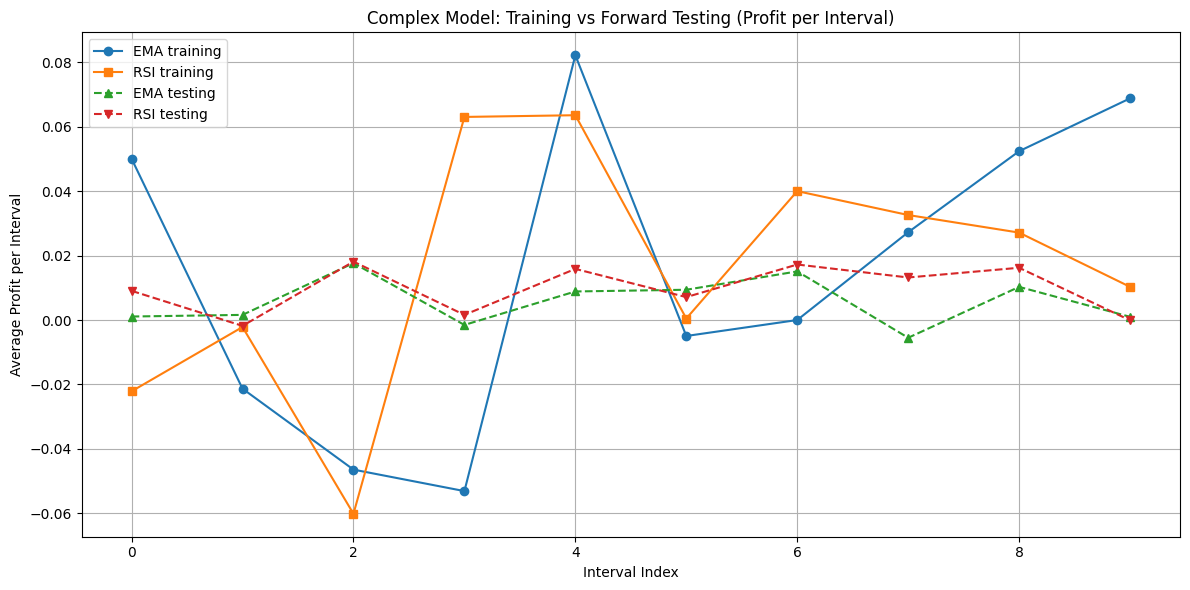

In [326]:
# Complex Model/Bayesian_testing.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load indicator data
data = pd.read_csv('Stocks Data/Airtel_indicator_values.csv', index_col=0, parse_dates=True)

# Load training results to get final posterior alpha/beta and returns
train_results = pd.read_csv('Complex Model/results_with_weighted_beta.csv')

# Initialize priors from final training results
prior = {
    'EMA_Crossover': {
        'alpha': train_results['EMA_alpha'].iloc[-1],
        'beta': train_results['EMA_beta'].iloc[-1],
        'mu': train_results['EMA_posterior_return'].iloc[-1],
        'tau2': 0.0004
    },
    'RSI_Strategy': {
        'alpha': train_results['RSI_alpha'].iloc[-1],
        'beta': train_results['RSI_beta'].iloc[-1],
        'mu': train_results['RSI_posterior_return'].iloc[-1],
        'tau2': 0.0004
    }
}

sigma2 = 0.0004
s = 100.0
M = 5.0

# Trading signals
data['EMA_signal'] = (data['EMA9'] > data['EMA21']).astype(int)
data['RSI_signal'] = (data['RSI'] < data['RSI_MA']).astype(int)
data['Return'] = (data['Close'].shift(-1) - data['Close']) / data['Close']
data = data.dropna().reset_index(drop=True)

# Forward testing data
test_data = data.iloc[2000:].copy()
interval_size = 20
trades_per_interval = 5
results = []

num_intervals = len(test_data) // interval_size

for idx in range(num_intervals):
    start = idx * interval_size
    end = start + interval_size
    interval_data = test_data.iloc[start:end]

    step = len(interval_data) // trades_per_interval
    trade_indices = np.arange(0, len(interval_data), step)[:trades_per_interval]

    profits = {s: [] for s in prior}

    for t_idx in trade_indices:
        row = interval_data.iloc[t_idx]
        r_t = row['Return']
        for strat in prior:
            signal_col = 'EMA_signal' if strat == 'EMA_Crossover' else 'RSI_signal'
            if row[signal_col] == 1:
                # Weighted Beta update
                c = np.clip(s * r_t, -M, M)
                prior[strat]['alpha'] += 1.0 + max(0.0, c)
                prior[strat]['beta']  += 1.0 + max(0.0, -c)

                # Normal-Normal update
                mu, tau2 = prior[strat]['mu'], prior[strat]['tau2']
                q_old = 1.0 / tau2
                q_new = q_old + 1.0 / sigma2
                mu_new = (q_old * mu + r_t / sigma2) / q_new
                tau2_new = 1.0 / q_new
                prior[strat]['mu'], prior[strat]['tau2'] = mu_new, tau2_new

                profits[strat].append(r_t)

    avg_profits = {s: np.mean(profits[s]) if profits[s] else 0.0 for s in prior}
    posterior_means = {s: prior[s]['alpha'] / (prior[s]['alpha'] + prior[s]['beta']) for s in prior}

    results.append({
        'Interval': idx,
        'EMA_interval_profit': avg_profits['EMA_Crossover'],
        'RSI_interval_profit': avg_profits['RSI_Strategy'],
        'EMA_posterior': posterior_means['EMA_Crossover'],
        'RSI_posterior': posterior_means['RSI_Strategy'],
        'EMA_posterior_return': prior['EMA_Crossover']['mu'],
        'RSI_posterior_return': prior['RSI_Strategy']['mu']
    })

# Save forward testing results
results_df = pd.DataFrame(results)
results_df.to_csv('Complex Model/forward_testing_profit.csv', index=False)
print("Forward-testing results (profit per interval) saved!")

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Strategy': ['EMA', 'RSI'],
    'Training_Mean': [
        train_results['EMA_interval_profit'].mean(),
        train_results['RSI_interval_profit'].mean()
    ],
    'Training_Var': [
        train_results['EMA_interval_profit'].var(ddof=1),
        train_results['RSI_interval_profit'].var(ddof=1)
    ],
    'Testing_Mean': [
        results_df['EMA_interval_profit'].mean(),
        results_df['RSI_interval_profit'].mean()
    ],
    'Testing_Var': [
        results_df['EMA_interval_profit'].var(ddof=1),
        results_df['RSI_interval_profit'].var(ddof=1)
    ]
})

print("\n--- Training vs Testing Profit per Interval Summary ---")
print(summary_stats.to_string(index=False))

# Plot: Training vs Testing Profit per Interval
plt.figure(figsize=(12,6))

# Align intervals visually
train_x = np.arange(len(train_results.tail(10)))
test_x = np.arange(len(results_df.head(10)))

plt.plot(train_x, train_results.tail(10)['EMA_interval_profit'], marker='o', label='EMA training')
plt.plot(train_x, train_results.tail(10)['RSI_interval_profit'], marker='s', label='RSI training')
plt.plot(test_x, results_df.head(10)['EMA_interval_profit'], marker='^', linestyle='--', label='EMA testing')
plt.plot(test_x, results_df.head(10)['RSI_interval_profit'], marker='v', linestyle='--', label='RSI testing')

plt.xlabel('Interval Index')
plt.ylabel('Average Profit per Interval')
plt.title('Complex Model: Training vs Forward Testing (Profit per Interval)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Complex Model/training_vs_testing_profit_per_interval.png")
plt.show()